In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("forest_cover.csv")

print(df.head())
print(df.shape)



   Unnamed: 0  Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0           0     3351.0     NaN   27.0                             726.0   
1           1     2732.0   129.0    7.0                             212.0   
2           2     2572.0    24.0    9.0                             201.0   
3           3     2824.0    69.0   13.0                             417.0   
4           4     2529.0    84.0    5.0                             120.0   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                           124.0                           3813.0   
1                             1.0                           1082.0   
2                           689.0                            957.0   
3                            39.0                           3223.0   
4                             9.0                           1092.0   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  ...  Soil_Type36  \
0          192.0           252.0            NaN

In [54]:
soil_columns = [f'Soil_Type{i}' for i in range(1, 41)] #Dealing with soil type
def handle_soil_types(df):
    soil_type_counts = df[soil_columns].sum()
    most_common = soil_type_counts.idxmax()
    df[soil_columns] = df[soil_columns].fillna(0)
    df[soil_columns] = df[soil_columns].astype('int64')
    def fix_row(row):# If a row does not have any Soil_Type flag of 1, it is replaced with most_common
        if 1 in row.values:
            return row
        else:
            return pd.Series([1 if col == most_common else 0 for col in soil_columns], index=soil_columns)
    df[soil_columns] = df[soil_columns].apply(fix_row, axis=1)
    return df
df = handle_soil_types(df)



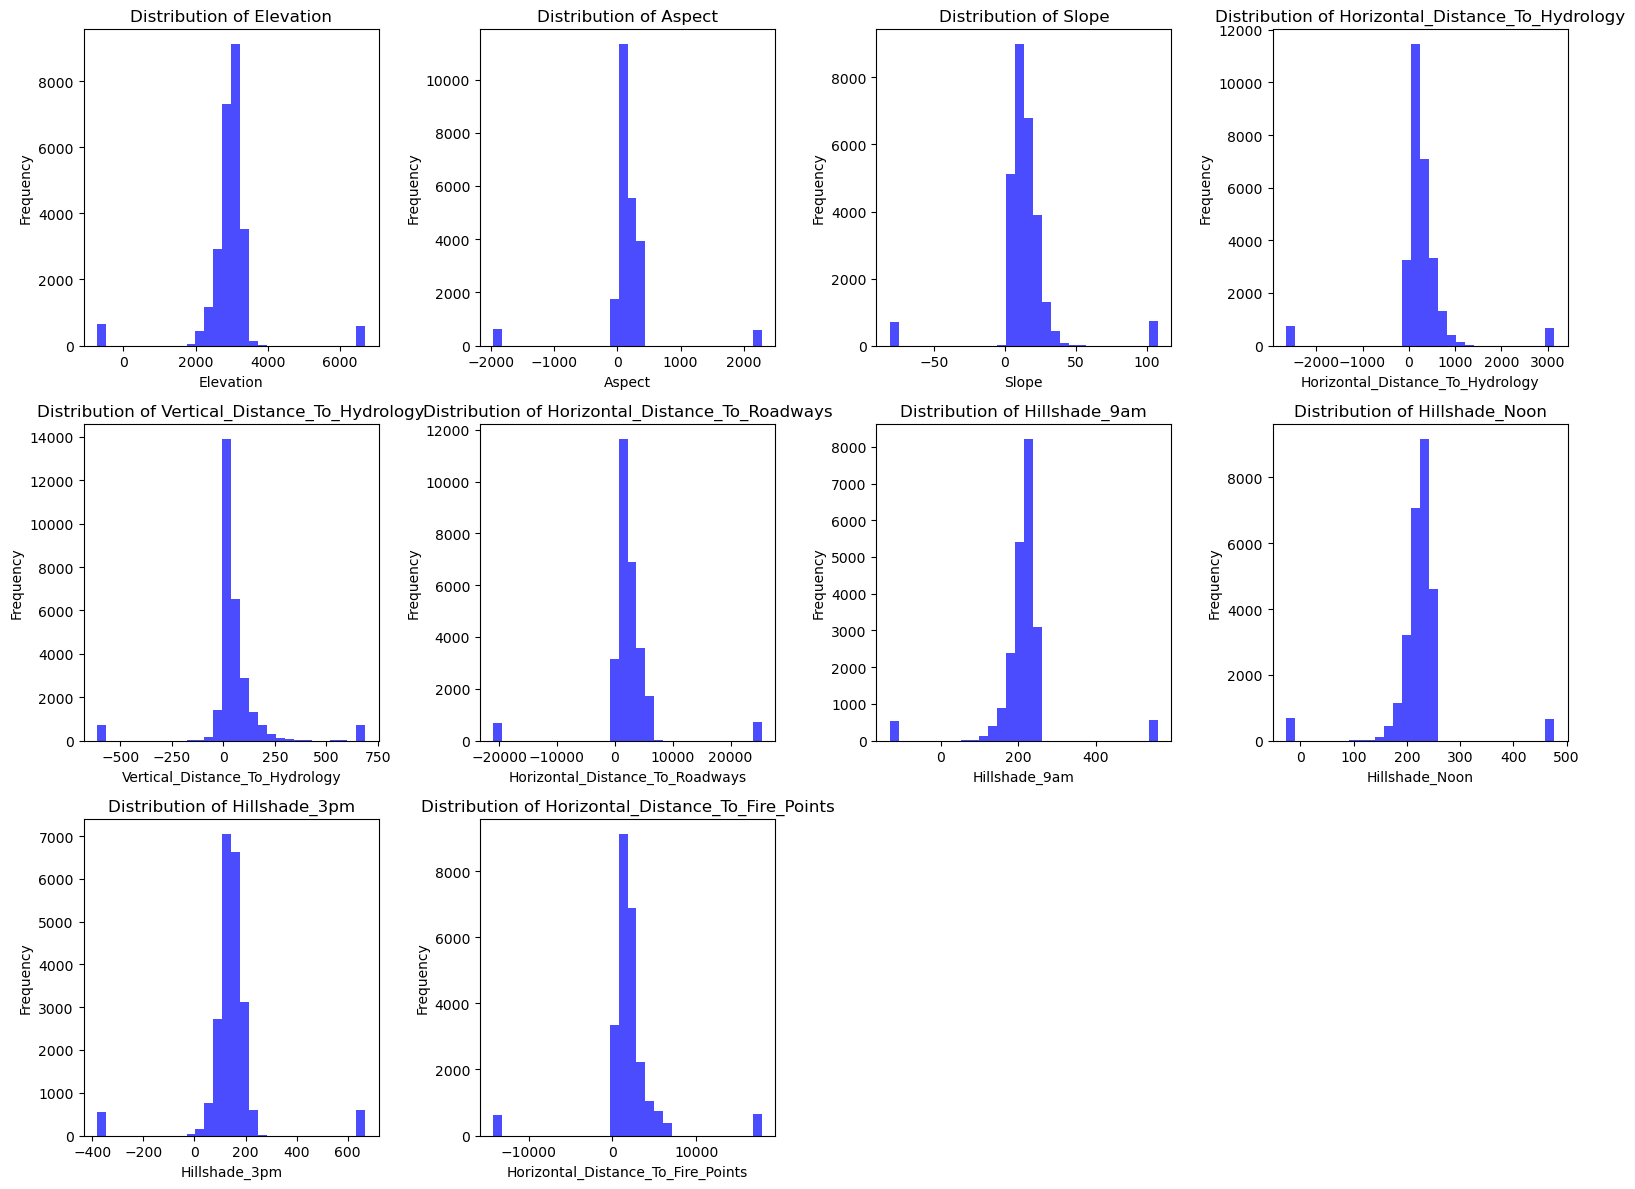

In [56]:
columns_of_interest = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology','Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
df_cleaned = df[columns_of_interest  + soil_columns + ['Forest_Cover', 'Neota', 'Rawah', 'Comanche Peak', 'Cache la Poudre']]

plt.figure(figsize=(16, 12)) # Plot the distribution histogram for each feature
for i, column in enumerate(columns_of_interest, 1):
    plt.subplot(3, 4, i)
    df_cleaned[column].plot(kind='hist', bins=30, color='blue', alpha=0.7)
    plt.title(f'Distribution of {column}', fontsize=12)
    plt.xlabel(f'{column}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [57]:
def process_values(df, col, lower=None, upper=None):
    df.loc[df[col] < 0, col] = np.nan
    if lower is not None:
        df = df[df[col] >= lower]
    if upper is not None:
        df = df[df[col] <= upper]
    return df


df_cleaned = process_values(df_cleaned, 'Elevation', lower=0, upper=6000) # Elevation: Fix negative numbers and remove values greater than 6000

df_cleaned = process_values(df_cleaned, 'Aspect', lower=0, upper=360) # Aspect: corrects negative numbers and removes values greater than 360

df_cleaned = process_values(df_cleaned, 'Slope', lower=0, upper=60) # Slope: corrects negative numbers and removes values greater than 60

df_cleaned = process_values(df_cleaned, 'Horizontal_Distance_To_Hydrology', upper=2000) # Horizontal_Distance_To_Hydrology: Includes negative correction, removes values greater than 2000

df_cleaned = process_values(df_cleaned, 'Vertical_Distance_To_Hydrology', lower=-250, upper=500) # Vertical_Distance_To_Hydrology: Negative values are allowed, and values less than -250 or greater than 500 are removed

df_cleaned = process_values(df_cleaned, 'Horizontal_Distance_To_Roadways', upper=20000) # Horizontal_Distance_To_Roadways: Includes negative corrections, removes values greater than 20000

df_cleaned = process_values(df_cleaned, 'Hillshade_9am', lower=0, upper=255)# Hillshade_9am, Hillshade_Noon, Hillshade_3pm: corrects negative values and removes values greater than 255
df_cleaned = process_values(df_cleaned, 'Hillshade_Noon', lower=0, upper=255)
df_cleaned = process_values(df_cleaned, 'Hillshade_3pm', lower=0, upper=255)

df_cleaned = process_values(df_cleaned, 'Horizontal_Distance_To_Fire_Points', upper=10000) # Horizontal_Distance_To_Fire_Points: Negative number fixes are included, removing values greater than 10000

In [58]:
for col in columns_of_interest:
    if df_cleaned[col].isnull().sum() > 0:
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)

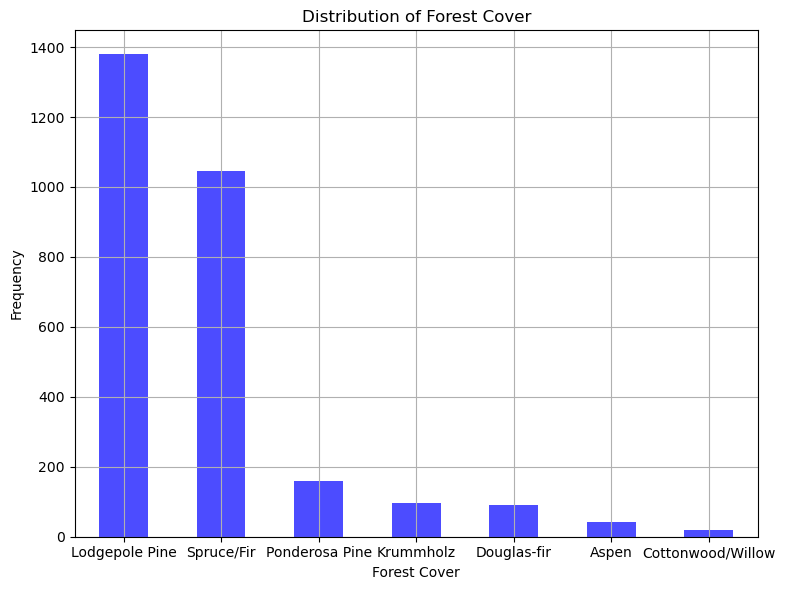

In [59]:
plt.figure(figsize=(8, 6))  # Plot the frequency histogram of Forest_Cover
df_cleaned['Forest_Cover'].value_counts().plot(kind='bar', color='blue', alpha=0.7)
plt.grid(True)
plt.title('Distribution of Forest Cover')
plt.xlabel('Forest Cover')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

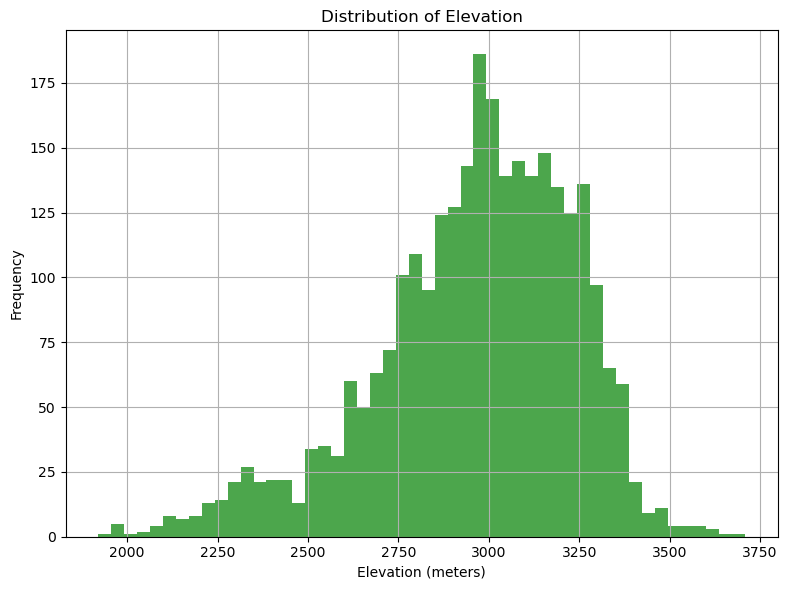

In [64]:
plt.figure(figsize=(8, 6))  # Plot the distribution histogram of Elevation
df_cleaned['Elevation'].plot(kind='hist', bins=50, color='green', alpha=0.7)
plt.grid(True)
plt.title('Distribution of Elevation')
plt.xlabel('Elevation (meters)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [66]:
df_cleaned.to_csv("cleaned_forest_cover.csv", index=False)